In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
x=torch.arange(1000)
x=x.unsqueeze(1)

In [3]:
x

tensor([[  0],
        [  1],
        [  2],
        [  3],
        [  4],
        [  5],
        [  6],
        [  7],
        [  8],
        [  9],
        [ 10],
        [ 11],
        [ 12],
        [ 13],
        [ 14],
        [ 15],
        [ 16],
        [ 17],
        [ 18],
        [ 19],
        [ 20],
        [ 21],
        [ 22],
        [ 23],
        [ 24],
        [ 25],
        [ 26],
        [ 27],
        [ 28],
        [ 29],
        [ 30],
        [ 31],
        [ 32],
        [ 33],
        [ 34],
        [ 35],
        [ 36],
        [ 37],
        [ 38],
        [ 39],
        [ 40],
        [ 41],
        [ 42],
        [ 43],
        [ 44],
        [ 45],
        [ 46],
        [ 47],
        [ 48],
        [ 49],
        [ 50],
        [ 51],
        [ 52],
        [ 53],
        [ 54],
        [ 55],
        [ 56],
        [ 57],
        [ 58],
        [ 59],
        [ 60],
        [ 61],
        [ 62],
        [ 63],
        [ 64],
        [ 65],
        [ 

In [4]:
w=0.9
b=2
y=w*x+b

In [5]:
y

tensor([[  2.0000],
        [  2.9000],
        [  3.8000],
        [  4.7000],
        [  5.6000],
        [  6.5000],
        [  7.4000],
        [  8.3000],
        [  9.2000],
        [ 10.1000],
        [ 11.0000],
        [ 11.9000],
        [ 12.8000],
        [ 13.7000],
        [ 14.6000],
        [ 15.5000],
        [ 16.4000],
        [ 17.3000],
        [ 18.2000],
        [ 19.1000],
        [ 20.0000],
        [ 20.9000],
        [ 21.8000],
        [ 22.7000],
        [ 23.6000],
        [ 24.5000],
        [ 25.4000],
        [ 26.3000],
        [ 27.2000],
        [ 28.1000],
        [ 29.0000],
        [ 29.9000],
        [ 30.8000],
        [ 31.7000],
        [ 32.6000],
        [ 33.5000],
        [ 34.4000],
        [ 35.3000],
        [ 36.2000],
        [ 37.1000],
        [ 38.0000],
        [ 38.9000],
        [ 39.8000],
        [ 40.7000],
        [ 41.6000],
        [ 42.5000],
        [ 43.4000],
        [ 44.3000],
        [ 45.2000],
        [ 46.1000],


In [6]:
device="mps" if torch.backends.mps.is_available() else "cpu"

In [7]:
x=x.to(device)
y=y.to(device)
print(device)


mps


In [8]:
limit=int(0.8*len(x))
x_train=x[:limit].type(torch.float32)
x_test=x[limit:].type(torch.float32)
y_test=y[limit:].type(torch.float32)
y_train=y[:limit].type(torch.float32)
print(x_train.dtype)
print(x_train)

torch.float32
tensor([[  0.],
        [  1.],
        [  2.],
        [  3.],
        [  4.],
        [  5.],
        [  6.],
        [  7.],
        [  8.],
        [  9.],
        [ 10.],
        [ 11.],
        [ 12.],
        [ 13.],
        [ 14.],
        [ 15.],
        [ 16.],
        [ 17.],
        [ 18.],
        [ 19.],
        [ 20.],
        [ 21.],
        [ 22.],
        [ 23.],
        [ 24.],
        [ 25.],
        [ 26.],
        [ 27.],
        [ 28.],
        [ 29.],
        [ 30.],
        [ 31.],
        [ 32.],
        [ 33.],
        [ 34.],
        [ 35.],
        [ 36.],
        [ 37.],
        [ 38.],
        [ 39.],
        [ 40.],
        [ 41.],
        [ 42.],
        [ 43.],
        [ 44.],
        [ 45.],
        [ 46.],
        [ 47.],
        [ 48.],
        [ 49.],
        [ 50.],
        [ 51.],
        [ 52.],
        [ 53.],
        [ 54.],
        [ 55.],
        [ 56.],
        [ 57.],
        [ 58.],
        [ 59.],
        [ 60.],
        [ 

In [9]:
torch.manual_seed(42)
model=nn.Sequential(
            nn.Linear(in_features=1,out_features=10),
            nn.Linear(in_features=10,out_features=1)
).to(device)
    

In [10]:
y_pre=model(x_test)
print(y_pre)

tensor([[234.3149],
        [234.6081],
        [234.9012],
        [235.1944],
        [235.4875],
        [235.7807],
        [236.0738],
        [236.3670],
        [236.6601],
        [236.9533],
        [237.2464],
        [237.5396],
        [237.8327],
        [238.1259],
        [238.4190],
        [238.7122],
        [239.0053],
        [239.2985],
        [239.5916],
        [239.8848],
        [240.1779],
        [240.4711],
        [240.7642],
        [241.0574],
        [241.3505],
        [241.6437],
        [241.9368],
        [242.2299],
        [242.5231],
        [242.8163],
        [243.1094],
        [243.4025],
        [243.6957],
        [243.9888],
        [244.2820],
        [244.5752],
        [244.8683],
        [245.1614],
        [245.4546],
        [245.7478],
        [246.0409],
        [246.3340],
        [246.6272],
        [246.9203],
        [247.2135],
        [247.5067],
        [247.7998],
        [248.0930],
        [248.3861],
        [248.6792],


In [11]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model.parameters(),lr=0.001)

In [12]:
epochs=3000
for epoch in range(epochs):
    model.train()
    y_pred=model(x_train)
    loss=loss_fn(y_pred,y_train)
    if(epoch%10==0):
        print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    
    

tensor(244.6415, device='mps:0', grad_fn=<MeanBackward0>)
tensor(108.0308, device='mps:0', grad_fn=<MeanBackward0>)
tensor(98.4724, device='mps:0', grad_fn=<MeanBackward0>)
tensor(78.2630, device='mps:0', grad_fn=<MeanBackward0>)
tensor(58.7375, device='mps:0', grad_fn=<MeanBackward0>)
tensor(40.3722, device='mps:0', grad_fn=<MeanBackward0>)
tensor(23.7369, device='mps:0', grad_fn=<MeanBackward0>)
tensor(10.7583, device='mps:0', grad_fn=<MeanBackward0>)
tensor(9.1858, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.9911, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7851, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.8034, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7925, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7818, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7713, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7611, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7512, device='mps:0', grad_fn=<MeanBackward0>)
tensor(8.7415, device='mps:0', grad_fn

In [13]:

with torch.inference_mode():
    model.eval()
    y_p=model(x_test)
print(y_p)


tensor([[727.9792],
        [728.8879],
        [729.7967],
        [730.7054],
        [731.6141],
        [732.5228],
        [733.4316],
        [734.3403],
        [735.2490],
        [736.1578],
        [737.0665],
        [737.9753],
        [738.8840],
        [739.7927],
        [740.7015],
        [741.6102],
        [742.5190],
        [743.4277],
        [744.3364],
        [745.2451],
        [746.1539],
        [747.0626],
        [747.9714],
        [748.8801],
        [749.7889],
        [750.6976],
        [751.6063],
        [752.5151],
        [753.4238],
        [754.3325],
        [755.2413],
        [756.1500],
        [757.0587],
        [757.9675],
        [758.8762],
        [759.7849],
        [760.6937],
        [761.6024],
        [762.5112],
        [763.4199],
        [764.3286],
        [765.2374],
        [766.1461],
        [767.0548],
        [767.9636],
        [768.8723],
        [769.7810],
        [770.6898],
        [771.5985],
        [772.5072],


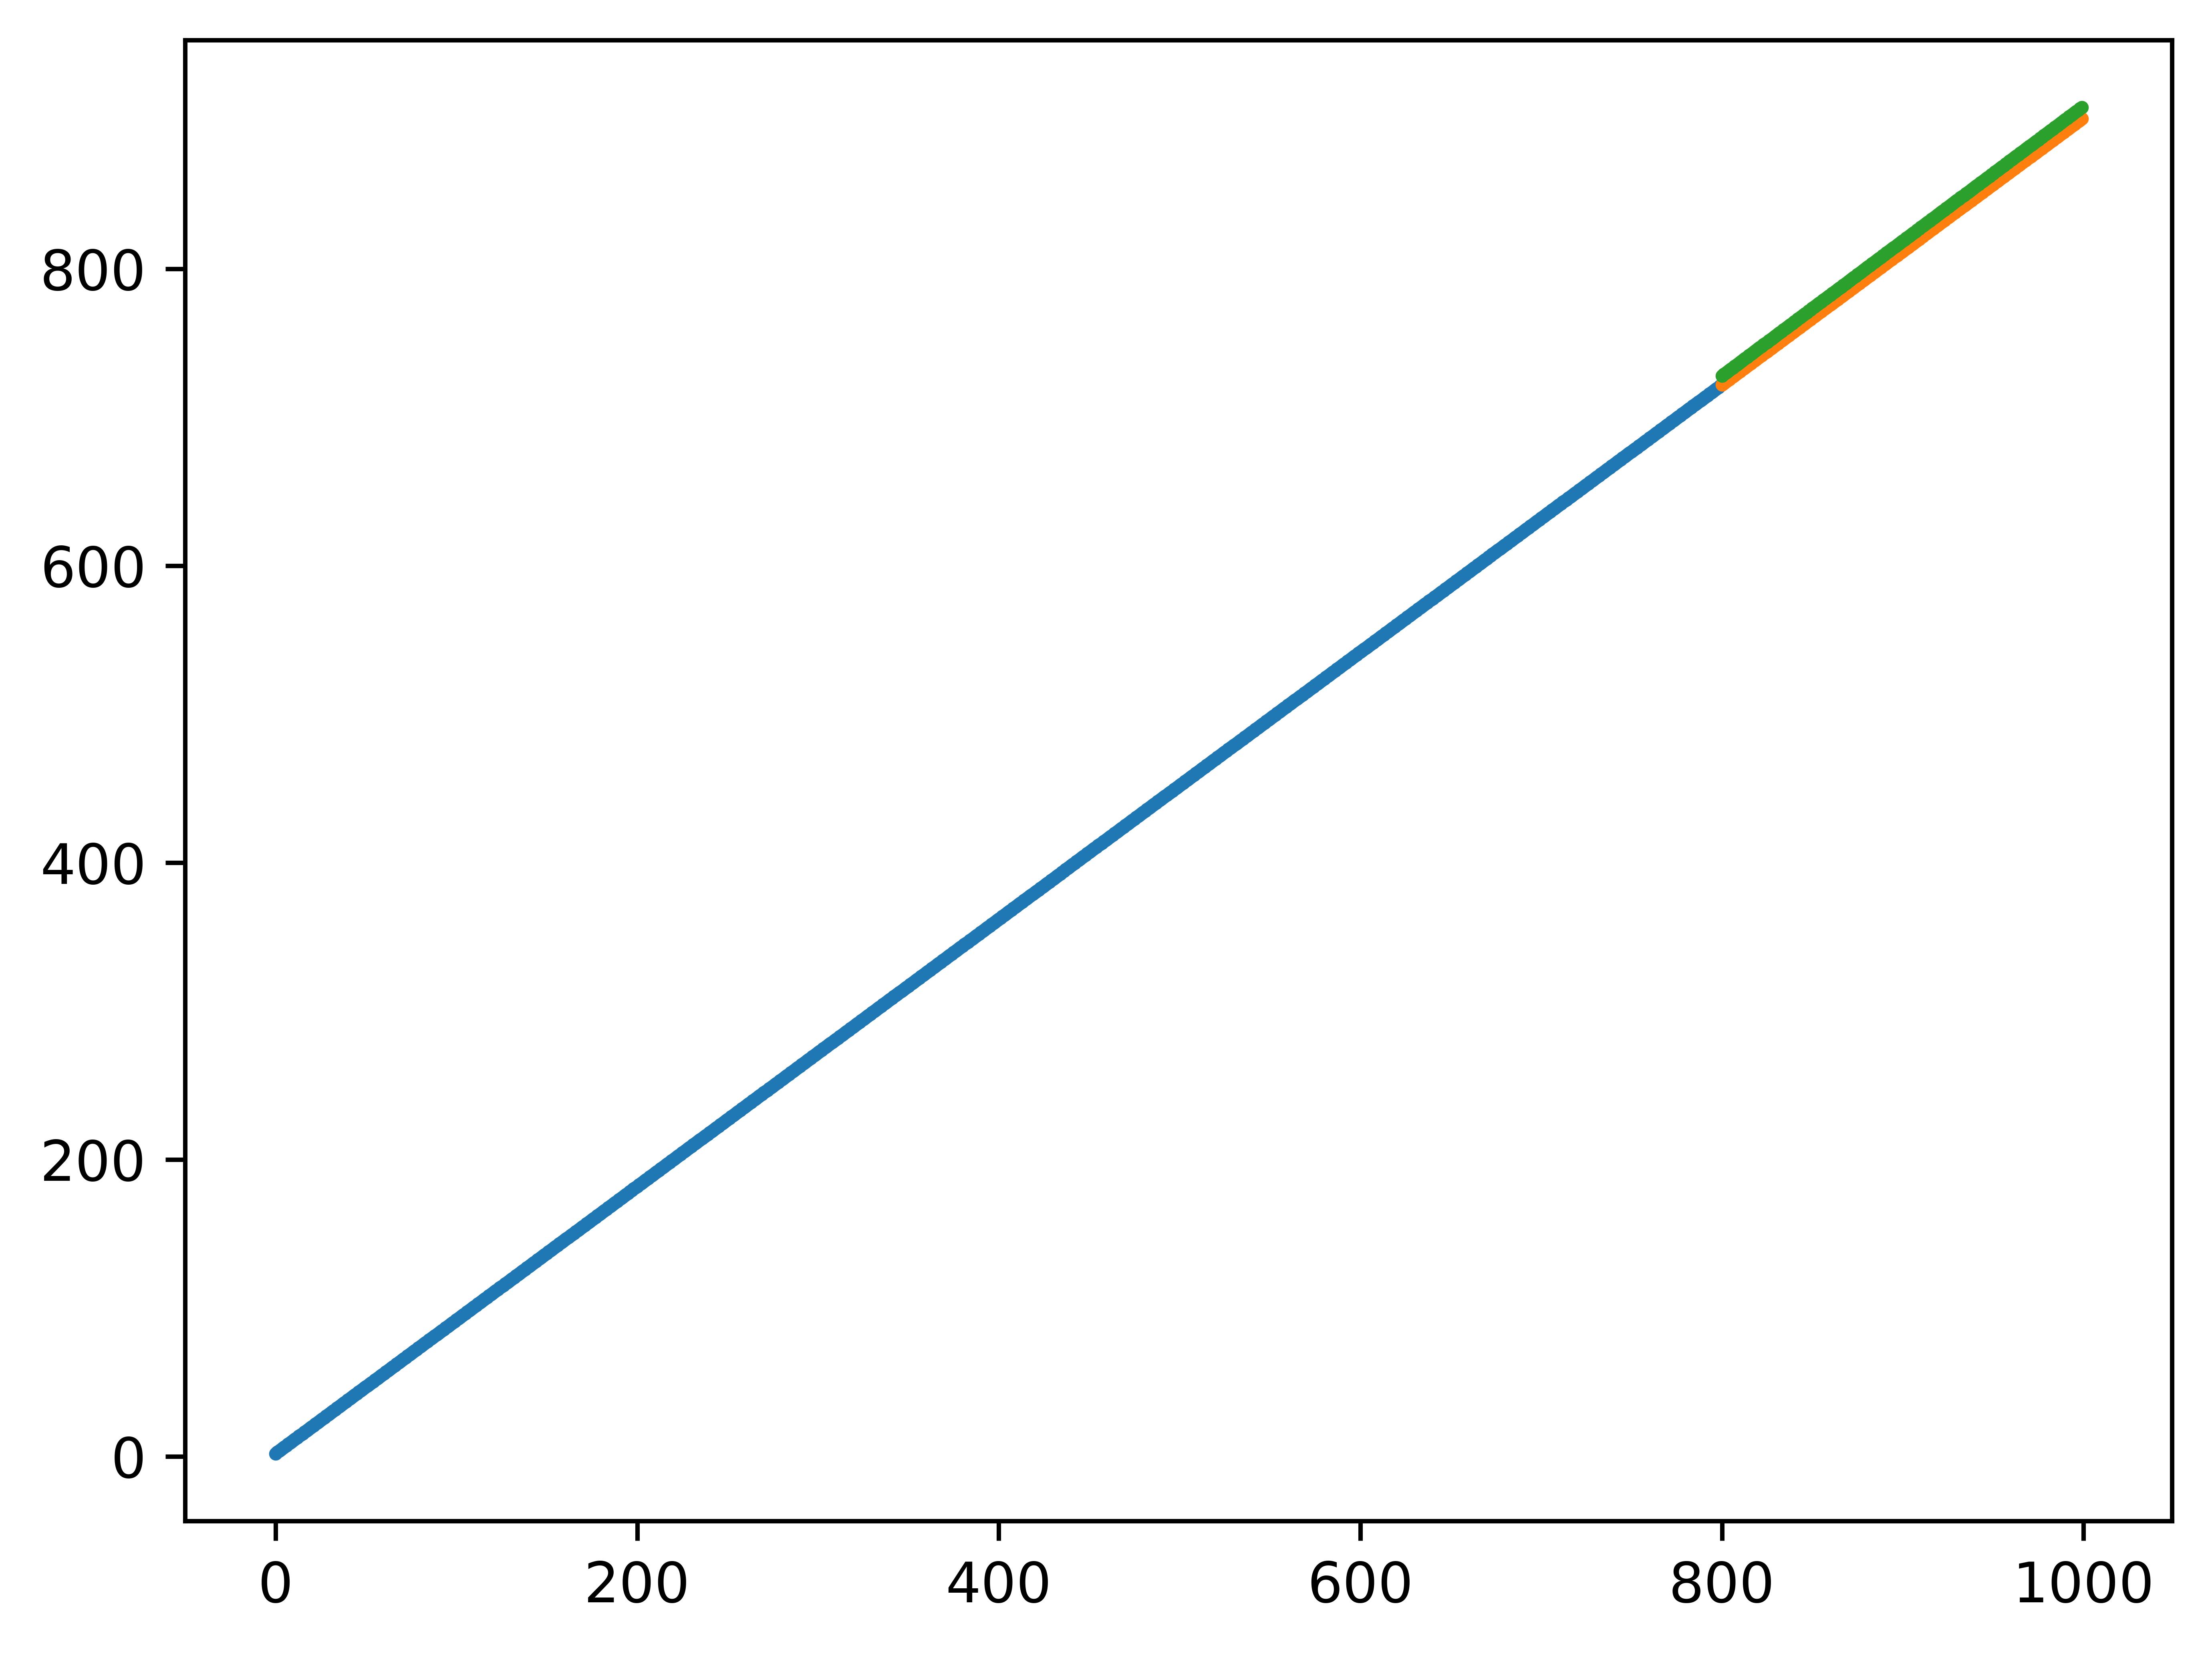

In [14]:

plt.figure(dpi=1000)
plt.scatter(x_train.to('cpu').numpy(),y_train.to('cpu').numpy(),s=2)
plt.scatter(x_test.to('cpu').numpy(),y_test.to('cpu').numpy(),s=2)
plt.scatter(x_test.to('cpu').numpy(),y_p.to('cpu').numpy(),s=2)